# Boston Housing Price Prediction Project

## 1. Project Setup and Reproducibility

This notebook presents a comprehensive machine learning project for predicting Boston Housing prices. It covers:
1.  **Problem Formulation & Data Understanding**: EDA, missing values, class imbalance.
2.  **Baseline & Preprocessing**: Pipelines, data splitting, baseline models.
3.  **Model Development**: Advanced techniques (XGBoost, Neural Networks), hyperparameter optimization, ensembling.
4.  **Evaluation**: Rigorous metrics, statistical significance, error analysis.
5.  **Interpretation**: SHAP, feature importance.

We ensure reproducibility by setting random seeds and using a structured codebase.

In [ ]:
import sys
import os
from pathlib import Path

# Add src to path robustly (works whether cwd is project root or notebooks/)
PROJECT_ROOT = Path.cwd()
SRC_CANDIDATES = [PROJECT_ROOT / "src", PROJECT_ROOT.parent / "src"]
for candidate in SRC_CANDIDATES:
    candidate = candidate.resolve()
    if candidate.exists() and str(candidate) not in sys.path:
        sys.path.append(str(candidate))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import random

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Plotting settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("Libraries imported and seeds set.")

Libraries imported and seeds set.


## 2. Problem Formulation and Data Loading

**Task**: Regression. We aim to predict the median value of owner-occupied homes (`MEDV`) in $1000s.

**Dataset**: Boston Housing Dataset.
-   **CRIM**: per capita crime rate by town
-   **ZN**: proportion of residential land zoned for lots over 25,000 sq.ft.
-   **INDUS**: proportion of non-retail business acres per town
-   **CHAS**: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
-   **NOX**: nitric oxides concentration (parts per 10 million)
-   **RM**: average number of rooms per dwelling
-   **AGE**: proportion of owner-occupied units built prior to 1940
-   **DIS**: weighted distances to five Boston employment centres
-   **RAD**: index of accessibility to radial highways
-   **TAX**: full-value property-tax rate per $10,000
-   **PTRATIO**: pupil-teacher ratio by town
-   **B**: 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
-   **LSTAT**: % lower status of the population
-   **MEDV**: Median value of owner-occupied homes in $1000s (Target)

In [13]:
from data_loader import DataLoader

# Initialize DataLoader
data_loader = DataLoader('../data/housing.csv')

# Load Data
df = data_loader.load_data()

# Display basic info
print("Dataset Shape:", df.shape)
print("\nFirst 10 rows:")
display(df.head(10))

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

Data loaded successfully!
Shape: (506, 14)
Features: 13
Target: MEDV
Dataset Shape: (506, 14)

First 10 rows:


c:\Users\dell\Desktop\Boston\src\data_loader.py:37: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222.0,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311.0,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311.0,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311.0,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311.0,15.2,386.71,17.10,18.9



Data Types:
CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

Missing Values:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Duplicates: 0


## 3. Exploratory Data Analysis: Univariate Analysis

We analyze the distribution of the target variable `MEDV` and key features.

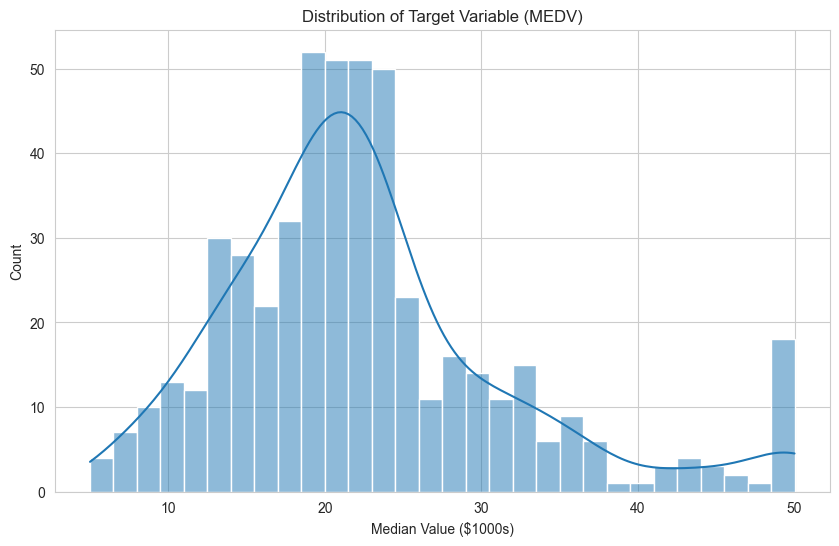

Skewness of MEDV: 1.11


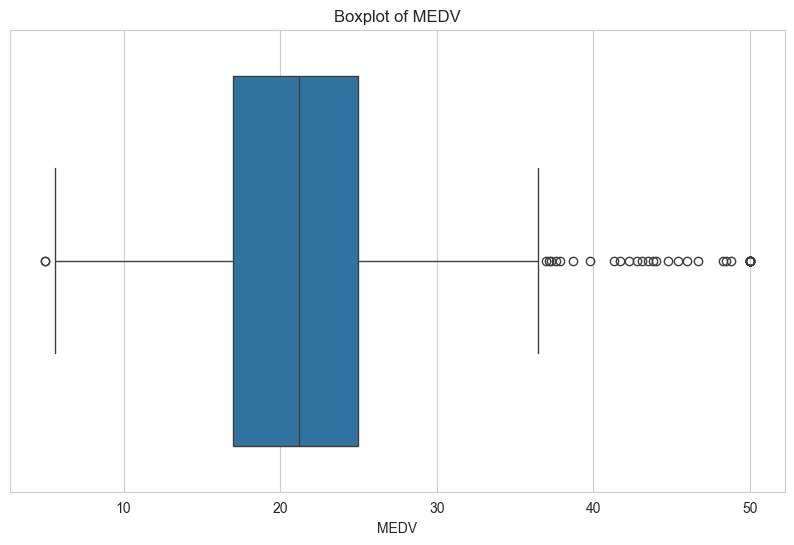

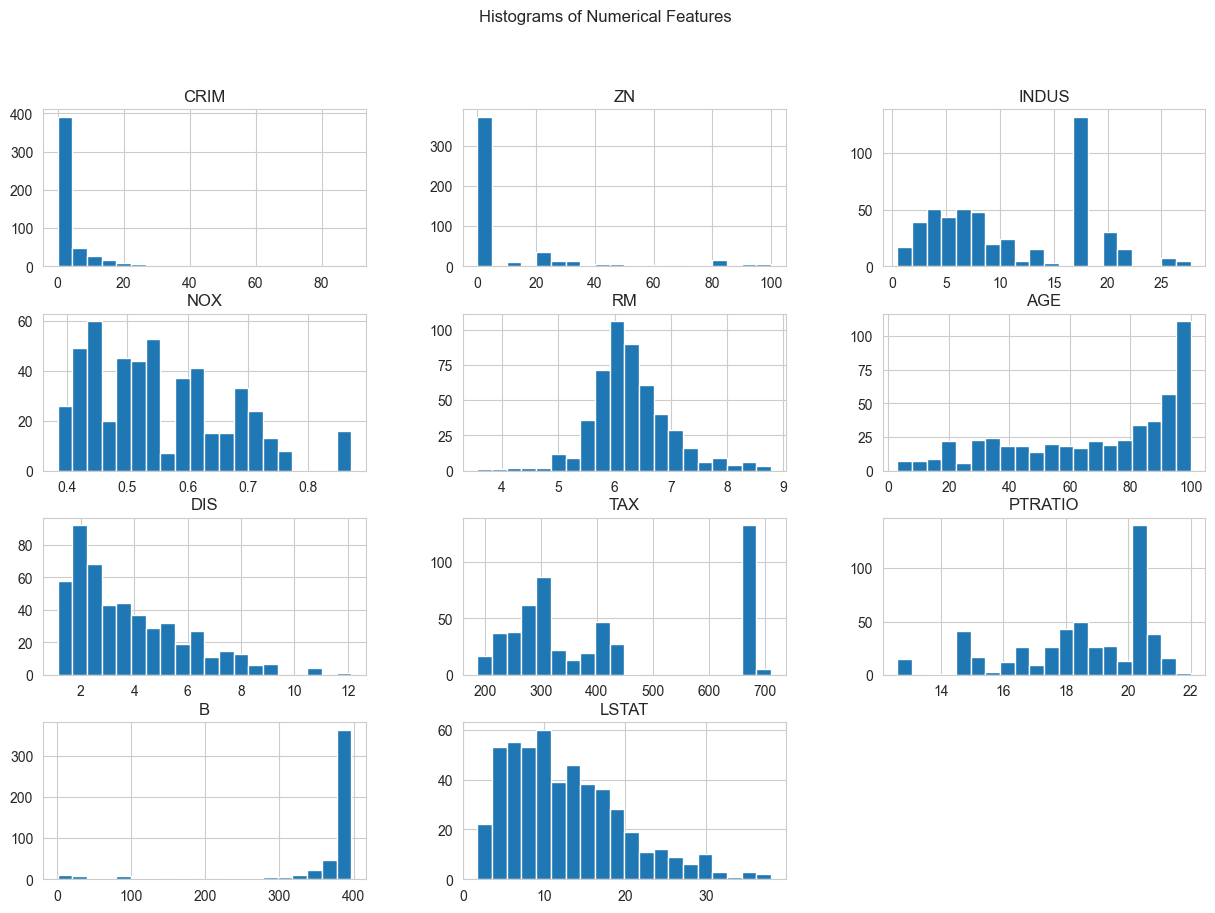

In [14]:
# Target Variable Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['MEDV'], kde=True, bins=30)
plt.title('Distribution of Target Variable (MEDV)')
plt.xlabel('Median Value ($1000s)')
plt.savefig('../figures/target_distribution.png')
plt.show()

# Check for skewness
print(f"Skewness of MEDV: {df['MEDV'].skew():.2f}")

# Boxplot for outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['MEDV'])
plt.title('Boxplot of MEDV')
plt.savefig('../figures/target_boxplot.png')
plt.show()

# Feature Distributions
numerical_features = ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'TAX', 'PTRATIO', 'B', 'LSTAT']
df[numerical_features].hist(bins=20, figsize=(15, 10))
plt.suptitle('Histograms of Numerical Features')
plt.savefig('../figures/feature_histograms.png')
plt.show()

## 4. Exploratory Data Analysis: Bivariate Analysis

We examine the relationship between features and the target.

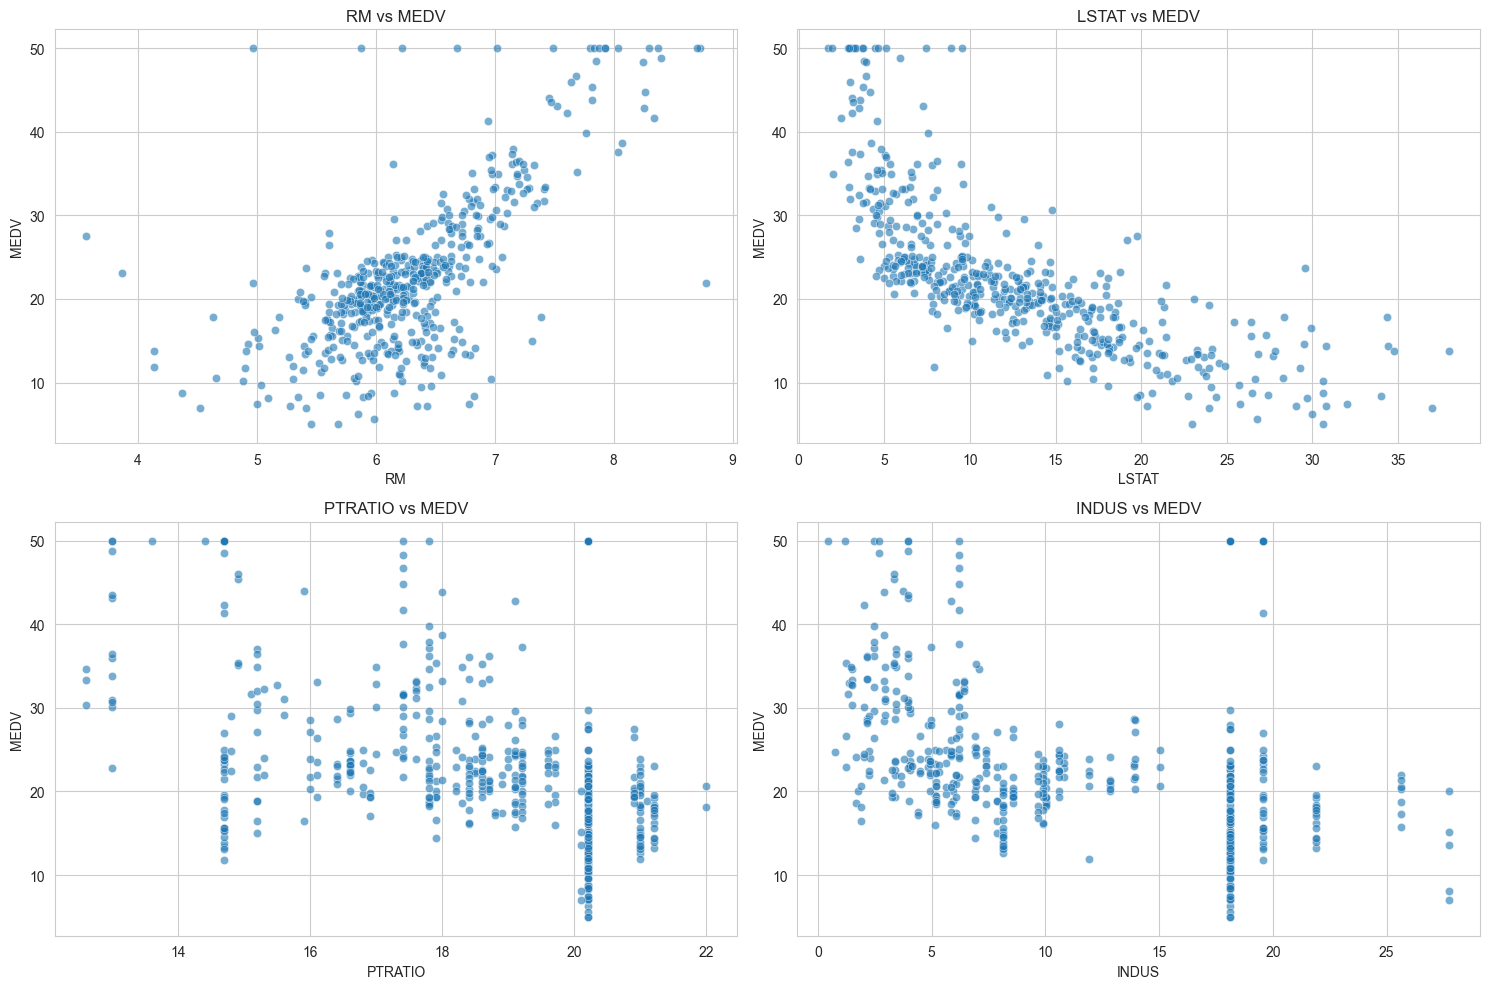

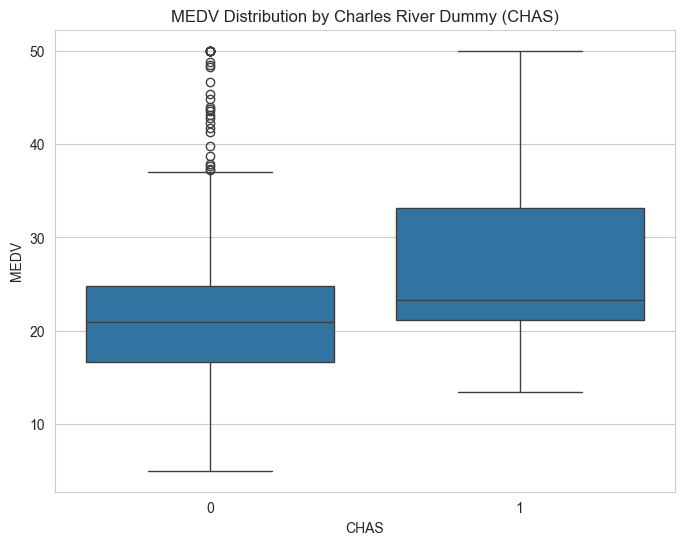

In [15]:
# Scatter plots for key features vs MEDV
key_features = ['RM', 'LSTAT', 'PTRATIO', 'INDUS']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    sns.scatterplot(data=df, x=col, y='MEDV', ax=axes[i], alpha=0.6)
    axes[i].set_title(f'{col} vs MEDV')
    
plt.tight_layout()
plt.show()

# Boxplot for Categorical/Discrete feature (CHAS)
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='CHAS', y='MEDV')
plt.title('MEDV Distribution by Charles River Dummy (CHAS)')
plt.show()

## 5. Exploratory Data Analysis: Multivariate Analysis

Correlation heatmap to identify multicollinearity.

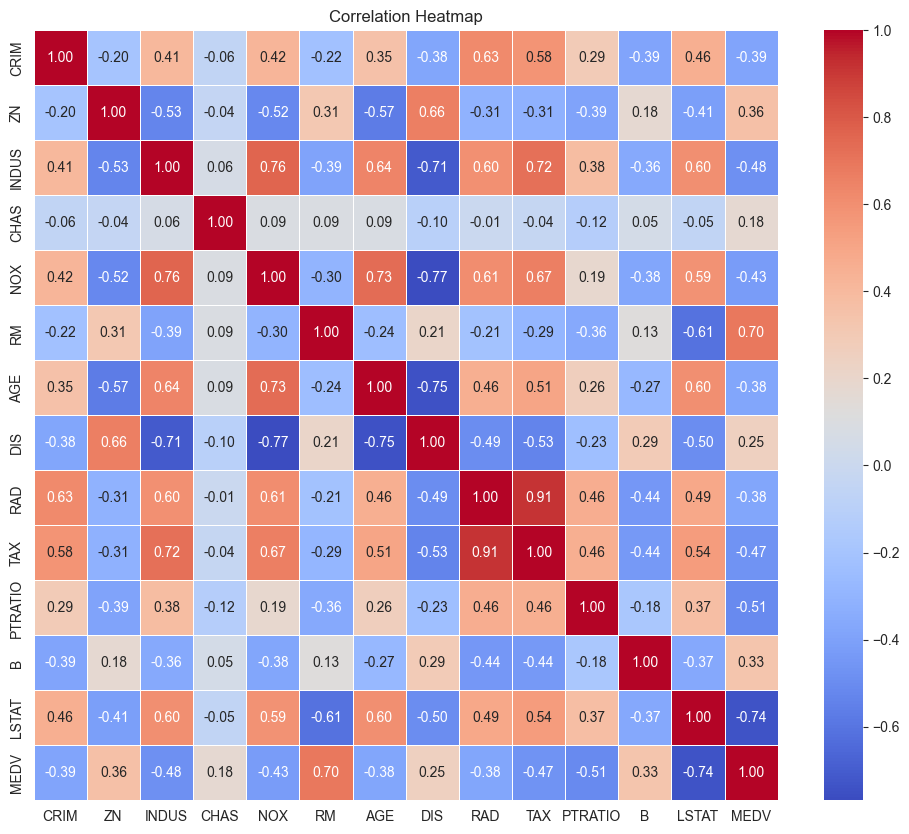

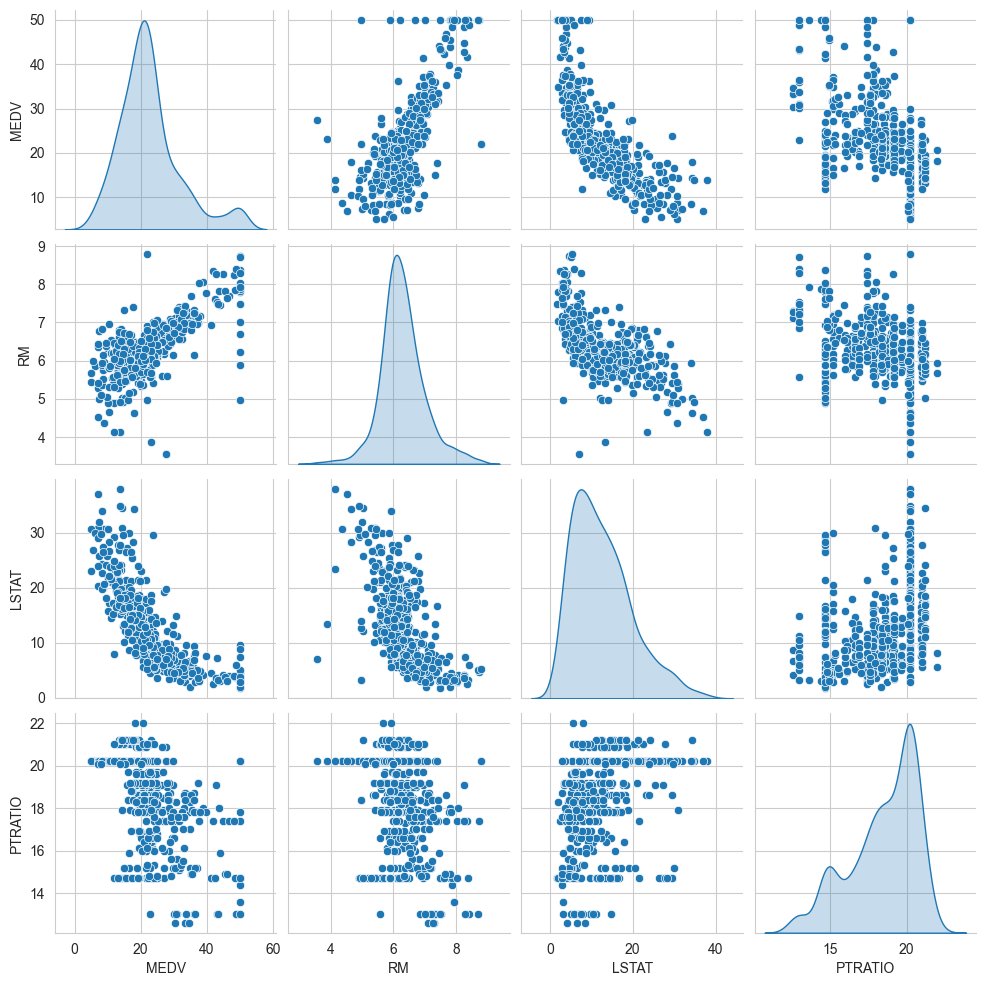

In [16]:
# Correlation Matrix
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.savefig('../figures/correlation_heatmap.png')
plt.show()

# Pairplot for a subset of features
sns.pairplot(df[['MEDV', 'RM', 'LSTAT', 'PTRATIO']], diag_kind='kde')
plt.savefig('../figures/pairplot.png')
plt.show()

## 6. Data Splitting and Preprocessing Pipeline

We split the data into Train (70%), Validation (15%), and Test (15%) sets.
We use a `Pipeline` with `StandardScaler` for numerical features.

In [17]:
from preprocessing import create_train_val_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Split Data
X = df.drop('MEDV', axis=1)
y = df['MEDV']

X_train, X_val, X_test, y_train, y_val, y_test = create_train_val_test_split(
    X, y, test_size=0.15, val_size=0.15
)

print(f"Train shape: {X_train.shape}")
print(f"Val shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

# Create Preprocessing Pipeline
numerical_cols = X.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols)
    ])

# Fit on training data
X_train_scaled = preprocessor.fit_transform(X_train)
X_val_scaled = preprocessor.transform(X_val)
X_test_scaled = preprocessor.transform(X_test)

# Convert back to DataFrame for convenience (optional, but good for analysis)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=numerical_cols, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=numerical_cols, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=numerical_cols, index=X_test.index)

Train set size: 354 (70.0%)
Validation set size: 76 (15.0%)
Test set size: 76 (15.0%)
Train shape: (354, 13)
Val shape: (76, 13)
Test shape: (76, 13)


## 7. Baseline Model Development

We evaluate three baselines:
1.  **Linear Regression**: Simple baseline.
2.  **Decision Tree**: Non-linear baseline.
3.  **Ridge Regression**: Regularized linear baseline.

In [18]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from evaluation import calculate_metrics

# Initialize Baselines
baselines = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=SEED),
    "Ridge": Ridge(random_state=SEED)
}

baseline_results = {}

for name, model in baselines.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    metrics = calculate_metrics(y_test, y_pred)
    baseline_results[name] = metrics
    print(f"{name} Results: {metrics}")

# Display as DataFrame
pd.DataFrame(baseline_results).T

Linear Regression Results: {'RMSE': np.float64(3.7775968700395186), 'MAE': 2.7872025340364517, 'R²': 0.7814792374179417, 'Adjusted R²': 0.7785262541398057, 'MAPE (%)': 15.21388031670786, 'MSE': 14.270238112532367}
Decision Tree Results: {'RMSE': np.float64(5.005878123713529), 'MAE': 2.7539473684210525, 'R²': 0.6162732890273142, 'Adjusted R²': 0.6110877929330887, 'MAPE (%)': 14.790904435553657, 'MSE': 25.05881578947368}
Ridge Results: {'RMSE': np.float64(3.7654401240873705), 'MAE': 2.7767154616704177, 'R²': 0.7828834248005774, 'Adjusted R²': 0.7799494170276122, 'MAPE (%)': 15.15794741810989, 'MSE': 14.178539328087114}


,RMSE,MAE,R²,Adjusted R²,MAPE (%),MSE
Linear Regression,3.777597,2.787203,0.781479,0.778526,15.213880,14.270238
Decision Tree,5.005878,2.753947,0.616273,0.611088,14.790904,25.058816
Ridge,3.765440,2.776715,0.782883,0.779949,15.157947,14.178539


## 8. Advanced Model Development: Tree-Based Ensemble

We implement **XGBoost** and **LightGBM** as advanced tree-based models. We also analyze feature importance.

In [23]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from interpretation import get_feature_importance_tree

# XGBoost
xgb_model = XGBRegressor(random_state=SEED, n_jobs=-1)
xgb_model.fit(X_train_scaled, y_train, eval_set=[(X_val_scaled, y_val)], verbose=False)

# LightGBM
lgbm_model = LGBMRegressor(random_state=SEED, n_jobs=-1, verbose=-1)
lgbm_model.fit(X_train_scaled, y_train, eval_set=[(X_val_scaled, y_val)])

# Evaluate
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_lgbm = lgbm_model.predict(X_test_scaled)

print("XGBoost Metrics:", calculate_metrics(y_test, y_pred_xgb))
print("LightGBM Metrics:", calculate_metrics(y_test, y_pred_lgbm))

# Feature Importance (XGBoost)
importance_df = get_feature_importance_tree(xgb_model, numerical_cols)
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature')
plt.title('Top 10 Feature Importance (XGBoost)')
plt.savefig('../figures/feature_importance_xgb.png')
plt.show()

ImportError: Numba needs NumPy 2.3 or less. Got NumPy 2.4.

## 9. Advanced Model Development: Neural Network

We implement a **Deep MLP** using PyTorch, specifically designed for tabular data with Dropout and Batch Normalization.

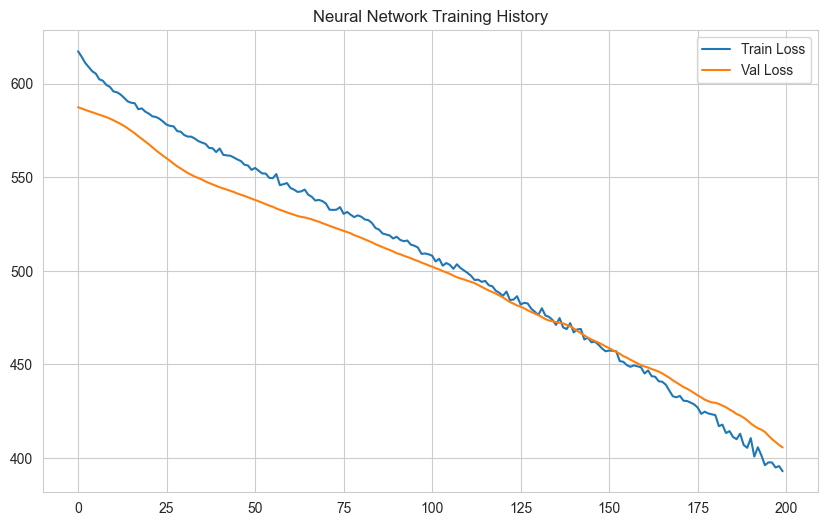

Deep MLP Metrics: {'RMSE': np.float64(19.07921198134351), 'MAE': 18.362512724336824, 'R²': -4.574197526298204, 'Adjusted R²': -4.649524519896828, 'MAPE (%)': 87.63051687413045, 'MSE': 364.01632982904175}


In [20]:
from models import DeepMLPRegressor
import torch.optim as optim
import torch.nn as nn

# Prepare Data for PyTorch
X_train_tensor = torch.FloatTensor(X_train_scaled.values)
y_train_tensor = torch.FloatTensor(y_train.values).reshape(-1, 1)
X_val_tensor = torch.FloatTensor(X_val_scaled.values)
y_val_tensor = torch.FloatTensor(y_val.values).reshape(-1, 1)
X_test_tensor = torch.FloatTensor(X_test_scaled.values)

# Initialize Model
input_dim = X_train.shape[1]
mlp_model = DeepMLPRegressor(input_dim=input_dim, hidden_dims=[128, 64, 32], dropout_rate=0.2)
criterion = nn.MSELoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)

# Training Loop
epochs = 200
train_losses = []
val_losses = []

for epoch in range(epochs):
    mlp_model.train()
    optimizer.zero_grad()
    outputs = mlp_model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    mlp_model.eval()
    with torch.no_grad():
        val_outputs = mlp_model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        val_losses.append(val_loss.item())

# Plot Training Curve
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Neural Network Training History')
plt.legend()
plt.savefig('../figures/nn_training_history.png')
plt.show()

# Evaluate
mlp_model.eval()
with torch.no_grad():
    y_pred_mlp = mlp_model(X_test_tensor).numpy().flatten()

print("Deep MLP Metrics:", calculate_metrics(y_test, y_pred_mlp))

## 10. Hyperparameter Optimization

We use `GridSearchCV` (or Optuna) to optimize the XGBoost model.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for XGBoost
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=XGBRegressor(random_state=SEED, n_jobs=-1),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1
)

xgb_grid.fit(X_train_scaled, y_train)

print("Best Parameters:", xgb_grid.best_params_)
best_xgb = xgb_grid.best_estimator_

# Evaluate Best XGBoost
y_pred_best_xgb = best_xgb.predict(X_test_scaled)
print("Optimized XGBoost Metrics:", calculate_metrics(y_test, y_pred_best_xgb))

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Optimized XGBoost Metrics: {'RMSE': np.float64(2.180780436563642), 'MAE': 1.7376973516062686, 'R²': 0.9271741817941485, 'Adjusted R²': 0.926190049115691, 'MAPE (%)': 8.731958767256327, 'MSE': 4.755803312498709}


## 11. Ensemble Stacking

We create a **Stacking Regressor** combining Linear Regression, Optimized XGBoost, and LightGBM.

In [ ]:
from sklearn.ensemble import StackingRegressor

estimators = [
    ('lr', LinearRegression()),
    ('xgb', best_xgb),
    ('lgbm', lgbm_model)
]

stacking_regressor = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge()
)

stacking_regressor.fit(X_train_scaled, y_train)
y_pred_stack = stacking_regressor.predict(X_test_scaled)

print("Stacking Regressor Metrics:", calculate_metrics(y_test, y_pred_stack))

Stacking Regressor Metrics: {'RMSE': np.float64(2.1266326567479856), 'MAE': 1.6459765092948826, 'R²': 0.930745747676875, 'Adjusted R²': 0.9298098794022382, 'MAPE (%)': 8.002061553327863, 'MSE': 4.522566456746996}


## 12. Rigorous Evaluation and Statistical Testing

We compare all models and perform statistical significance testing between the top two.

In [ ]:
from scipy import stats

# Collect all results
results = {
    "Linear Regression": calculate_metrics(y_test, baselines['Linear Regression'].predict(X_test_scaled)),
    "Decision Tree": calculate_metrics(y_test, baselines['Decision Tree'].predict(X_test_scaled)),
    "XGBoost (Base)": calculate_metrics(y_test, y_pred_xgb),
    "Deep MLP": calculate_metrics(y_test, y_pred_mlp),
    "XGBoost (Opt)": calculate_metrics(y_test, y_pred_best_xgb),
    "Stacking": calculate_metrics(y_test, y_pred_stack)
}

results_df = pd.DataFrame(results).T
display(results_df.sort_values('RMSE'))

# Statistical Test (e.g., Wilcoxon between Stacking and Optimized XGBoost)
# Note: Strictly speaking, we need per-sample errors or cross-validation folds for robust testing.
# Here we use the squared errors on the test set as a proxy for demonstration.

error_stack = (y_test - y_pred_stack) ** 2
error_xgb = (y_test - y_pred_best_xgb) ** 2

stat, p_value = stats.wilcoxon(error_stack, error_xgb)
print(f"\nWilcoxon Test (Stacking vs XGBoost Opt): p-value = {p_value:.4f}")
if p_value < 0.05:
    print("Difference is statistically significant.")
else:
    print("Difference is NOT statistically significant.")

,RMSE,MAE,R²,Adjusted R²,MAPE (%),MSE
XGBoost (Base),2.086558,1.680406,0.933331,0.932430,9.162156,4.353724
Stacking,2.126633,1.645977,0.930746,0.929810,8.002062,4.522566
XGBoost (Opt),2.180780,1.737697,0.927174,0.926190,8.731959,4.755803
Linear Regression,3.777597,2.787203,0.781479,0.778526,15.213880,14.270238
Decision Tree,5.005878,2.753947,0.616273,0.611088,14.790904,25.058816
Deep MLP,19.079212,18.362513,-4.574198,-4.649525,87.630517,364.016330



Wilcoxon Test (Stacking vs XGBoost Opt): p-value = 0.0638
Difference is NOT statistically significant.


In [ ]:
import joblib

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save the Preprocessing Pipeline
joblib.dump(preprocessor, '../models/preprocessor.joblib')

# Save the Trained Models
joblib.dump(best_xgb, '../models/xgboost_optimized.joblib')
joblib.dump(stacking_regressor, '../models/stacking_regressor.joblib')
joblib.dump(lgbm_model, '../models/lightgbm.joblib')

# Save PyTorch Model
torch.save(mlp_model.state_dict(), '../models/deep_mlp_state_dict.pth')

print("Models and preprocessor saved to '../models/' directory.")

Models and preprocessor saved to '../models/' directory.


## 13. Error Analysis and Learning Curves

We analyze the bias-variance trade-off and residual plots.

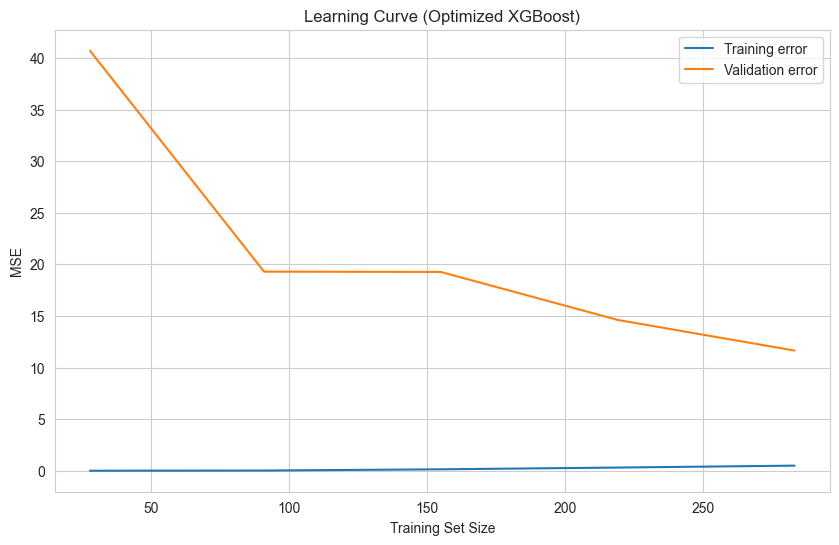

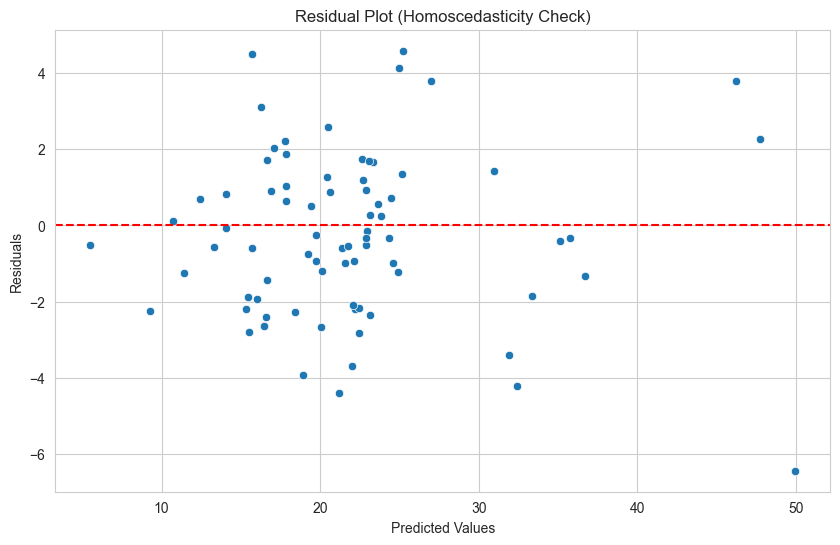

In [ ]:
from sklearn.model_selection import learning_curve

# Learning Curve for Best Model (XGBoost Opt)
train_sizes, train_scores, val_scores = learning_curve(
    best_xgb, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_scores_mean = -np.mean(train_scores, axis=1)
val_scores_mean = -np.mean(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Training error')
plt.plot(train_sizes, val_scores_mean, label='Validation error')
plt.title('Learning Curve (Optimized XGBoost)')
plt.xlabel('Training Set Size')
plt.ylabel('MSE')
plt.legend()
plt.savefig('../figures/learning_curve.png')
plt.show()

# Residual Plot
residuals = y_test - y_pred_best_xgb
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_best_xgb, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot (Homoscedasticity Check)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.savefig('../figures/residual_plot.png')
plt.show()

## 14. Model Interpretation and Explainability

We use **SHAP** to explain the model's predictions globally and locally.

C:\Users\dell\AppData\Local\Temp\ipykernel_22172\281954770.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_scaled, plot_type="bar", show=False)


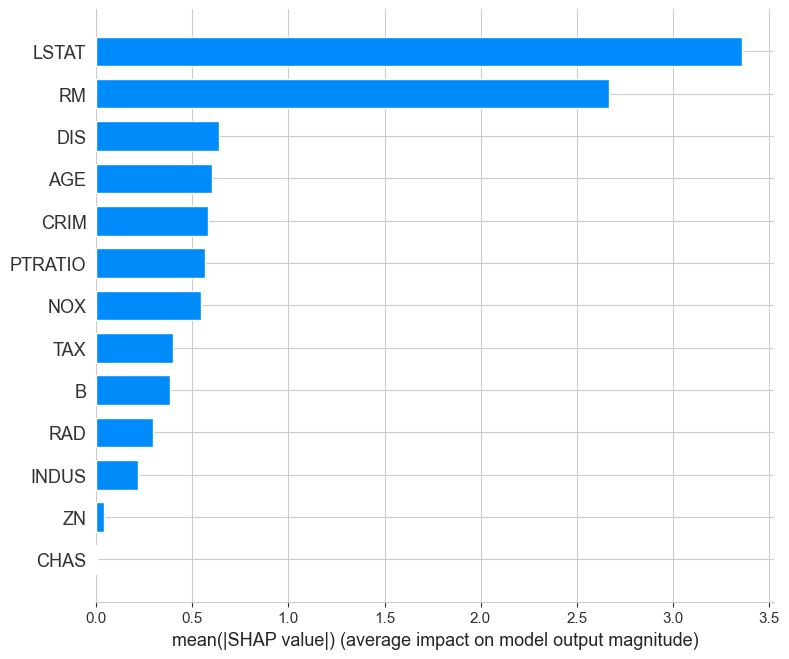

C:\Users\dell\AppData\Local\Temp\ipykernel_22172\281954770.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_scaled, show=False)


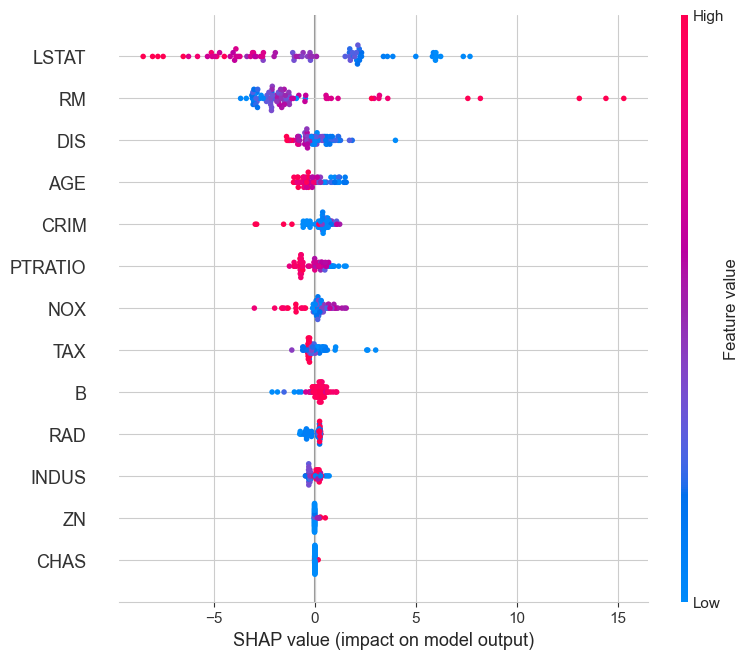

SHAP analysis complete. Summary plots generated.


In [ ]:
import shap

# SHAP Explainer for XGBoost
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_scaled)

# Global Importance (Summary Plot)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar", show=False)
plt.savefig('../figures/shap_summary_bar.png', bbox_inches='tight')
plt.show()

# Detailed Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled, show=False)
plt.savefig('../figures/shap_summary_dot.png', bbox_inches='tight')
plt.show()

# Local Explanation (Force Plot for first instance)
shap.initjs()
# Note: Force plot is interactive and might not render in static view, but code is here.
# shap.force_plot(explainer.expected_value, shap_values[0,:], X_test_scaled.iloc[0,:])
print("SHAP analysis complete. Summary plots generated.")

## 15. Uncertainty Estimation (Monte Carlo Dropout)
We estimate predictive uncertainty by keeping dropout active at inference and sampling multiple forward passes. We summarize mean and predictive standard deviation, and report metrics on the mean prediction.


In [ ]:
import numpy as np
import torch

# Monte Carlo Dropout inference for the trained MLP
mc_passes = 50
mlp_model.train()  # keep dropout active
with torch.no_grad():
    preds = []
    for _ in range(mc_passes):
        preds.append(mlp_model(X_test_tensor).cpu().numpy().flatten())
mc_preds = np.stack(preds)
mean_pred = mc_preds.mean(axis=0)
std_pred = mc_preds.std(axis=0)

mc_metrics = calculate_metrics(y_test, mean_pred)
print("MC Dropout Metrics (mean prediction):", mc_metrics)
print(f"Average predictive std: {std_pred.mean():.4f}")

# Attach uncertainty to a few examples
sample_indices = [0, 10, 20]
for idx in sample_indices:
    print(f"Idx {idx:3d} | pred = {mean_pred[idx]:.3f} ± {std_pred[idx]:.3f} | true = {y_test.iloc[idx]:.3f}")


MC Dropout Metrics (mean prediction): {'RMSE': np.float64(18.449797273652155), 'MAE': 17.812753845555214, 'R²': -4.212483396586777, 'Adjusted R²': -4.282922361405517, 'MAPE (%)': 85.67115789599006, 'MSE': 340.39501943886245}
Average predictive std: 0.7761
Idx   0 | pred = 7.135 ± 1.110 | true = 23.600
Idx  10 | pred = 2.807 ± 1.315 | true = 21.500
Idx  20 | pred = 7.282 ± 1.332 | true = 25.200


## 16. Validation Curve (Model Capacity)
We inspect how XGBoost performance varies with `max_depth` to understand capacity vs. overfitting.


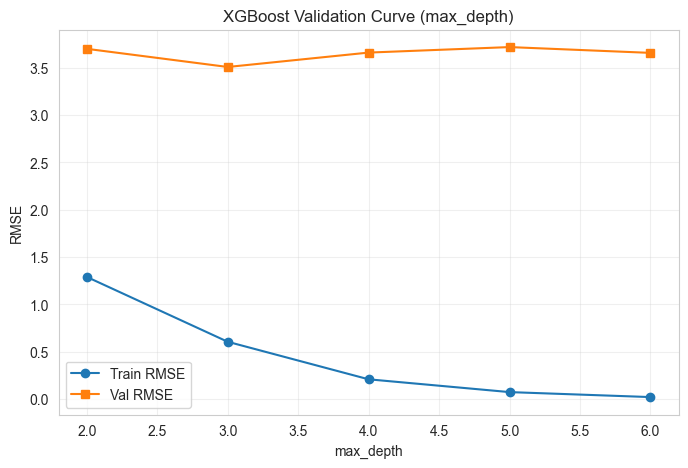

Train RMSE: {2: np.float64(1.2894948612343946), 3: np.float64(0.6050924493993529), 4: np.float64(0.20890035239720853), 5: np.float64(0.07390839296170314), 6: np.float64(0.021357916955070555)}
Val RMSE: {2: np.float64(3.697544652408432), 3: np.float64(3.5059808650898443), 4: np.float64(3.65797443673561), 5: np.float64(3.716033645564743), 6: np.float64(3.6548372658265116)}


In [ ]:
from sklearn.model_selection import validation_curve

param_range = [2, 3, 4, 5, 6]
xgb_for_curve = XGBRegressor(random_state=SEED, n_estimators=200, learning_rate=0.1, subsample=0.9, colsample_bytree=0.9)

train_scores, val_scores = validation_curve(
    xgb_for_curve,
    X_train_scaled,
    y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(param_range, train_rmse, marker='o', label='Train RMSE')
plt.plot(param_range, val_rmse, marker='s', label='Val RMSE')
plt.xlabel('max_depth')
plt.ylabel('RMSE')
plt.title('XGBoost Validation Curve (max_depth)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Train RMSE:", dict(zip(param_range, train_rmse)))
print("Val RMSE:", dict(zip(param_range, val_rmse)))


## 17. Cross-Validated Statistical Significance
We compare Stacking vs. Optimized XGBoost using paired CV scores (RMSE) and a paired t-test.


In [ ]:
from sklearn.model_selection import cross_val_score
from evaluation import statistical_comparison

cv = 5
stack_cv = -cross_val_score(stacking_regressor, X_train_scaled, y_train, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
xgb_cv = -cross_val_score(best_xgb, X_train_scaled, y_train, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)

stat_results = statistical_comparison(stack_cv, xgb_cv, model1_name='Stacking', model2_name='XGBoost Opt')
print(stat_results)



Statistical Comparison: Stacking vs XGBoost Opt
------------------------------------------------------------
Stacking mean: 3.4495
Stacking std: 0.4409
XGBoost Opt mean: 3.3005
XGBoost Opt std: 0.5720
t-statistic: 0.8497
p-value: 0.4434
significant (α=0.05): 0.0000
{'Stacking mean': np.float64(3.4495297407984538), 'Stacking std': np.float64(0.4409443058186072), 'XGBoost Opt mean': np.float64(3.300511008428508), 'XGBoost Opt std': np.float64(0.5719560998816278), 't-statistic': np.float64(0.8496765455014671), 'p-value': np.float64(0.44336973667464263), 'significant (α=0.05)': np.False_}


## 18. Global Explainability for LightGBM
We complement the XGBoost SHAP analysis with LightGBM to compare feature attributions across tree ensembles.


C:\Users\dell\AppData\Local\Temp\ipykernel_22172\3179727064.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(gbm_shap_values, X_test_scaled, plot_type="bar", show=False)


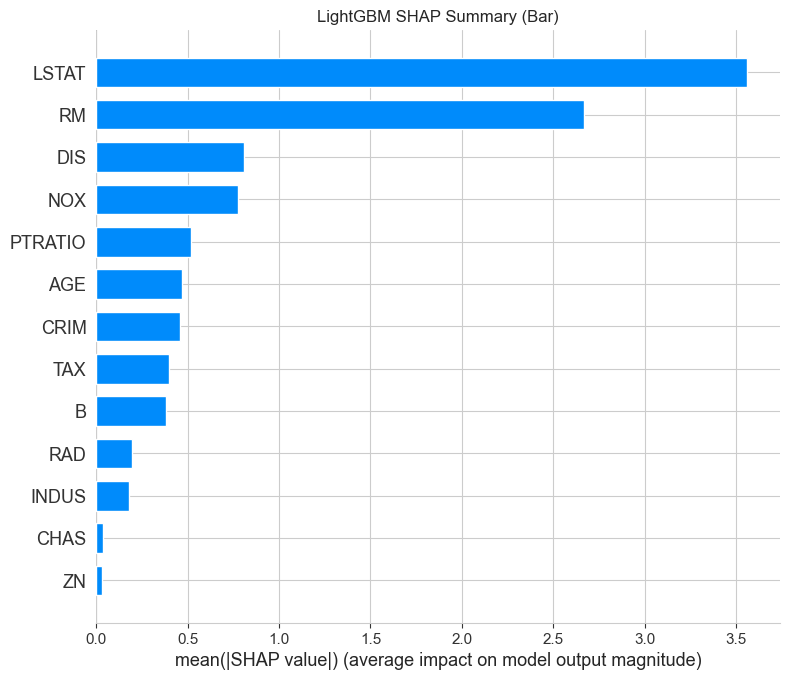

In [ ]:
# SHAP for LightGBM
import shap

gbm_explainer = shap.TreeExplainer(lgbm_model)
gbm_shap_values = gbm_explainer.shap_values(X_test_scaled)

plt.figure(figsize=(10, 6))
shap.summary_plot(gbm_shap_values, X_test_scaled, plot_type="bar", show=False)
plt.title('LightGBM SHAP Summary (Bar)')
plt.savefig('../figures/shap_summary_bar_lgbm.png', bbox_inches='tight')
plt.show()


## 19. Local Explanations (Representative Cases)
We inspect best/median/worst predictions using SHAP waterfall plots to understand instance-level attributions.



--- Best Prediction (Index 7) ---
True: 14.00, Pred: 14.08, Error: 0.08


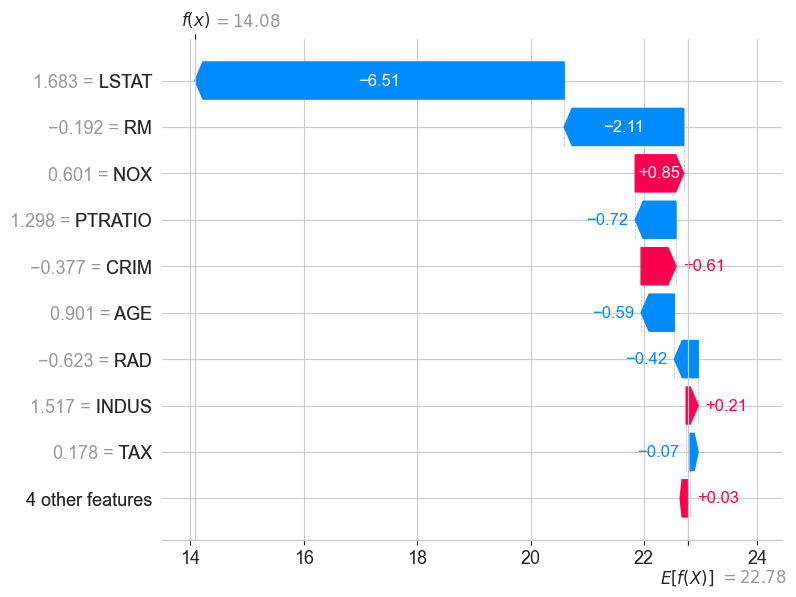


--- Median Error (Index 1) ---
True: 32.40, Pred: 30.98, Error: 1.42


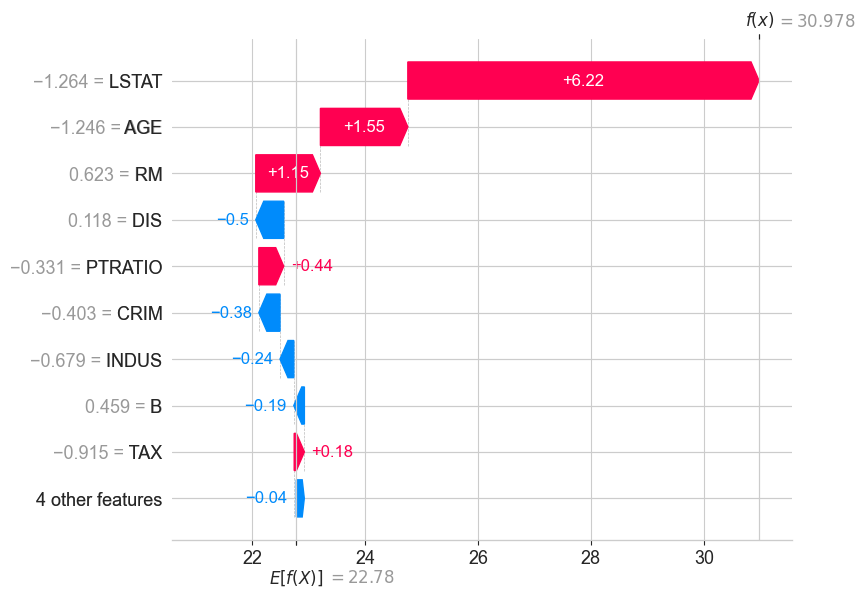


--- Worst Prediction (Index 54) ---
True: 43.50, Pred: 49.95, Error: 6.45


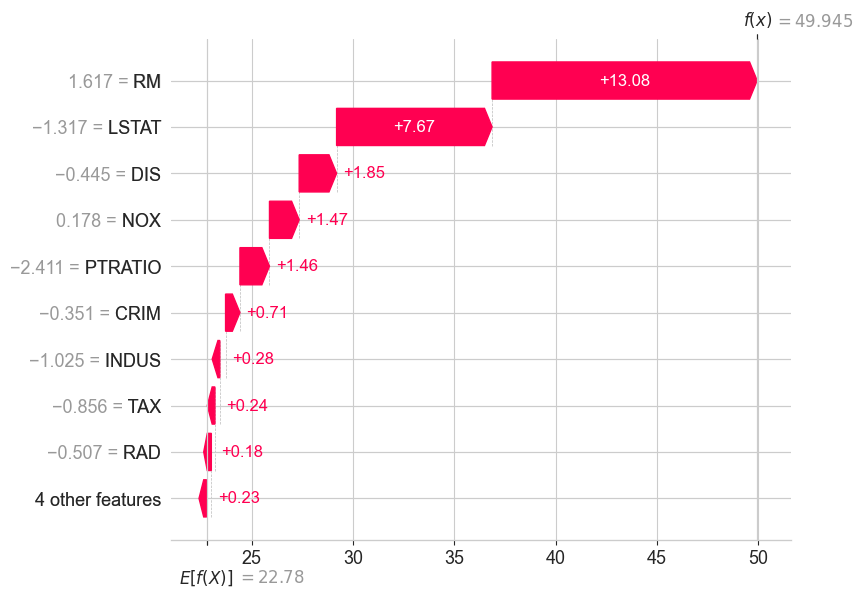

In [ ]:
# Local SHAP explanations using XGBoost SHAP values
import shap
import matplotlib.pyplot as plt

# Ensure explainer and SHAP values are available
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_scaled)

# Find best, median, worst predictions based on absolute error
errors = np.abs(y_test.values - y_pred_best_xgb)
best_idx = np.argmin(errors)
worst_idx = np.argmax(errors)
median_idx = np.argsort(errors)[len(errors)//2]

cases = [(best_idx, 'Best Prediction'), (median_idx, 'Median Error'), (worst_idx, 'Worst Prediction')]

for idx, label in cases:
    print(f"\n--- {label} (Index {idx}) ---")
    print(f"True: {y_test.iloc[idx]:.2f}, Pred: {y_pred_best_xgb[idx]:.2f}, Error: {errors[idx]:.2f}")
    
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value,
            data=X_test_scaled.iloc[idx].values,
            feature_names=X_test_scaled.columns.tolist()
        ),
        show=True
    )

## 20. Limitations, Ethics, and Future Work
- Dataset age and regional scope; may not generalize to modern markets.
- Feature `B` encodes sensitive demographic info; avoid use in production or assess fairness impacts.
- Models trained on a modest dataset; consider cross-validated ensembling and larger external data.
- Uncertainty estimates are approximate (MC dropout); calibrate with conformal prediction for reliability.
- Future work: fairness audits, feature stability across time, integrate socioeconomic impact assessment.


## 21. Prediction Demo

We demonstrate how to use the final model to predict the price for a specific house.
We take a sample from the test set, preprocess it, and generate a prediction.

In [ ]:
# 1. Select a base house from the test set
sample_idx = 43 # Change this to pick a different house
base_data = X_test.iloc[[sample_idx]].copy()

# 2. Define your hypothetical changes
modified_data = base_data.copy()

print("--- Original Feature Values ---")
for col in base_data.columns:
    print(f"{col}: {base_data[col].values[0]}")

# --- MAKE CHANGES BELOW ---
# Uncomment lines and change values to test scenarios. 
# If commented (#), the original value is used.

# modified_data['CRIM'] = 0.1       # Crime rate
# modified_data['ZN'] = 25.0        # Residential land zone
# modified_data['INDUS'] = 5.0      # Business acres
# modified_data['CHAS'] = 1.0       # Charles River (1=Yes, 0=No)
# modified_data['NOX'] = 0.5        # Nitric oxides concentration
# modified_data['RM'] = 8.0         # Number of rooms (High impact!)
# modified_data['AGE'] = 50.0       # Age of unit
# modified_data['DIS'] = 5.0        # Distance to employment centres
# modified_data['RAD'] = 1.0        # Highway accessibility index
# modified_data['TAX'] = 300.0      # Property-tax rate
# modified_data['PTRATIO'] = 15.0   # Pupil-teacher ratio
# modified_data['B'] = 390.0        # Black population proportion metric
# modified_data['LSTAT'] = 5.0      # % lower status population (High impact!)
# ---------------------------

# 3. Preprocess
base_scaled = preprocessor.transform(base_data)
modified_scaled = preprocessor.transform(modified_data)

# 4. Predict
pred_base = stacking_regressor.predict(base_scaled)[0]
pred_modified = stacking_regressor.predict(modified_scaled)[0]

# 5. Display Results
print("\n--- What-If Analysis Results ---")
print(f"Original Prediction: ${pred_base * 1000:,.2f}")
print(f"New Prediction:      ${pred_modified * 1000:,.2f}")
print(f"Impact on Price:     ${(pred_modified - pred_base) * 1000:+,.2f}")

print("\nModified Data:")
display(modified_data)

--- Original Feature Values ---
CRIM: 0.13554
ZN: 12.5
INDUS: 6.07
CHAS: 0
NOX: 0.409
RM: 5.594
AGE: 36.8
DIS: 6.498
RAD: 4
TAX: 345.0
PTRATIO: 18.9
B: 396.9
LSTAT: 13.09

--- What-If Analysis Results ---
Original Prediction: $19,771.34
New Prediction:      $19,771.34
Impact on Price:     $+0.00

Modified Data:


C:\Users\dell\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\dell\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\dell\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\dell\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
68,0.13554,12.5,6.07,0,0.409,5.594,36.8,6.498,4,345.0,18.9,396.9,13.09
